In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [2]:
X = pd.read_csv("X_scaled.csv")

y = pd.read_csv("y.csv").squeeze()

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
y_pred = model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.795


In [7]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.6818181818181818


In [8]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.30612244897959184


In [9]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.4225352112676056


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.95      0.88       151
           1       0.68      0.31      0.42        49

    accuracy                           0.80       200
   macro avg       0.75      0.63      0.65       200
weighted avg       0.78      0.80      0.76       200



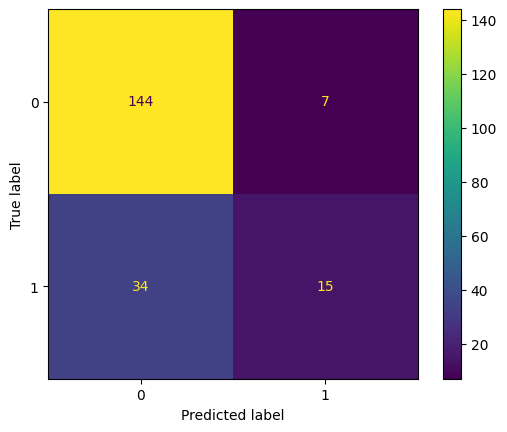

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

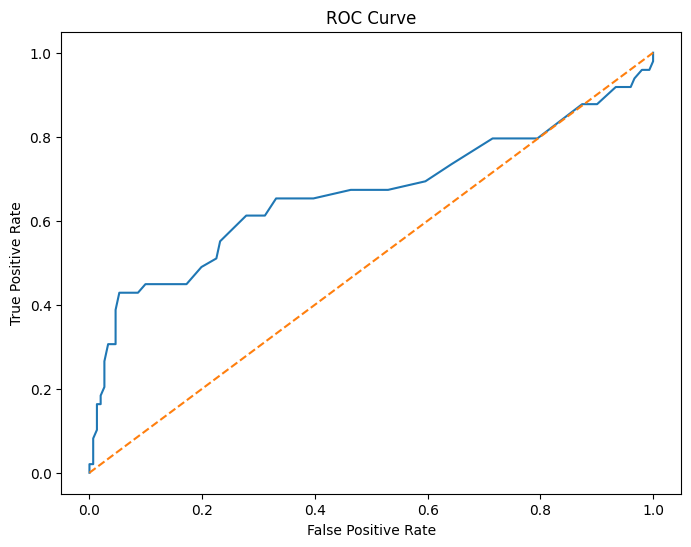

In [12]:
probability = model.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(
    y_test,
    probability
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [13]:
roc_auc = roc_auc_score(
    y_test,
    probability
)

print("ROC AUC Score :", roc_auc)

ROC AUC Score : 0.6642789566157589


In [14]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,MonthlyCharges,0.173957
5,TotalCharges,0.168576
3,Tenure,0.155937
0,CustomerID,0.110854
10,MonthlyUsageGB,0.110718
1,Age,0.104081
11,NumComplaints,0.050022
9,PaymentMethod,0.037155
6,ContractType,0.030550
2,Gender,0.020582


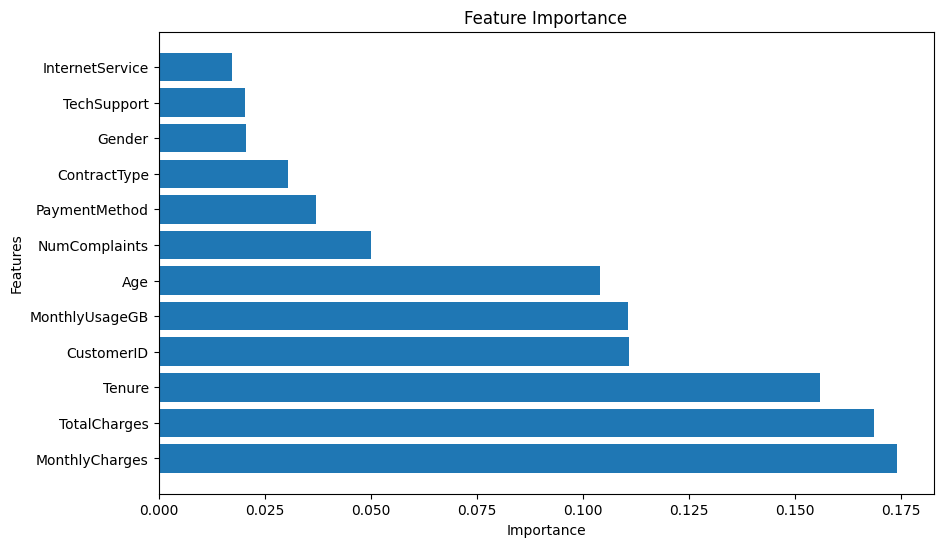

In [15]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [16]:
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

results

,Metric,Value
0,Accuracy,0.795000
1,Precision,0.681818
2,Recall,0.306122
3,F1 Score,0.422535
4,ROC AUC,0.664279
